## Test

In [1]:
import numpy as np
import pandas as pd

for i in [4,8,16,32]:
# 加载 .npz 文件
    data = np.load('../singleset/2DHolstein25_chi{}.npz'.format(i),allow_pickle=True)

    # 'mol list', 'tempearture', 'total time', 'other info', 'r square array', 
    # 'electron occupations array', 'phonon occupations array', 'k occupations array', 
    # 'eph entropy', 'bond entropy', 'coherent length array', 'time series'
    df = data['electron occupations array']

    df = pd.DataFrame(df)

    df.to_excel('2DHolstein25_chi{}_singleset.xlsx'.format(i), index=False)

## Plot Occupation



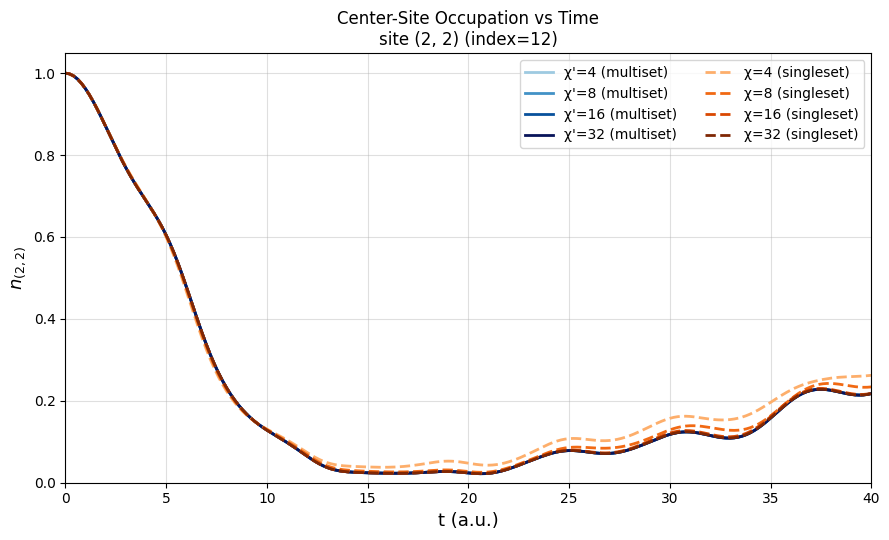

In [2]:
# =========================
# Plot center-site occupation vs time
# Edit the file lists below just like the RMSD block above.
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Basic parameters
# =========================
dt = 0.2  # a.u.
lattice_shape = (5, 5)
center_site = (2, 2)
center_label = f'({center_site[0]},{center_site[1]})'

# =========================
# Helper functions
# =========================
def load_occupations(file_path):
    df = pd.read_excel(file_path, header=None)
    # If the Excel file was exported with the default column header 0..N-1, drop it.
    if np.array_equal(df.iloc[0].to_numpy(), np.arange(df.shape[1])):
        df = df.iloc[1:].reset_index(drop=True)
    return df.to_numpy(dtype=float)

def compute_site_occupation(file_path, site=center_site, lattice_shape=lattice_shape):
    occup = load_occupations(file_path)
    Nt, Nsite = occup.shape
    nrow, ncol = lattice_shape
    if nrow * ncol != Nsite:
        raise ValueError(f'lattice_shape={lattice_shape} does not match Nsite={Nsite}')

    site_index = site[0] * ncol + site[1]  # row-major flattening
    if not (0 <= site_index < Nsite):
        raise ValueError(f'site {site} is out of range for lattice_shape={lattice_shape}')

    time_au = np.arange(Nt) * dt
    return time_au, occup[:, site_index], site_index

# =========================
# Files to plot (edit these lists as needed)
# =========================
files_multiset = [
    ("χ'=4", "2DHolstein25_chi4_multiset.xlsx"),
    ("χ'=8", "2DHolstein25_chi8_multiset.xlsx"),
    ("χ'=16", "2DHolstein25_chi16_multiset.xlsx"),
    ("χ'=32", "2DHolstein25_chi32_multiset.xlsx"),
]

files_singleset = [
    ("χ=4", "2DHolstein25_chi4_singleset.xlsx"),
    ("χ=8", "2DHolstein25_chi8_singleset.xlsx"),
    ("χ=16", "2DHolstein25_chi16_singleset.xlsx"),
    ("χ=32", "2DHolstein25_chi32_singleset.xlsx"),
]

# =========================
# Colors and styles
# =========================
colors_multiset = ["#9ecae1", "#4292c6", "#08519c", "#08145a"]
colors_singleset = ["#fdae6b", "#f16913", "#d94801", "#7f2704"]

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(9, 5.5))
site_index = center_site[0] * lattice_shape[1] + center_site[1]

for (label, file_path), color in zip(files_multiset, colors_multiset):
    try:
        time, occ, _ = compute_site_occupation(file_path)
        ax.plot(time, occ, lw=2, ls='-', color=color, label=f'{label} (multiset)')
    except FileNotFoundError:
        print(f'[Warning] 文件未找到，已跳过：{file_path}')

for (label, file_path), color in zip(files_singleset, colors_singleset):
    try:
        time, occ, _ = compute_site_occupation(file_path)
        ax.plot(time, occ, lw=2, ls='--', color=color, label=f'{label} (singleset)')
    except FileNotFoundError:
        print(f'[Warning] 文件未找到，已跳过：{file_path}')

# =========================
# Figure settings
# =========================
ax.set_xlim(0, 40)
ax.set_ylim(bottom=0)
ax.set_xlabel('t (a.u.)', fontsize=13)
ax.set_ylabel(rf'$n_{{{center_label}}}$', fontsize=13)
ax.set_title(f'Center-Site Occupation vs Time\nsite {center_site} (index={site_index})', fontsize=12)
ax.legend(fontsize=10, ncol=2, loc='upper right')
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()


,library,ansatz,chi,file,n_points
0,pyttn,multiset,4,holstein2d25_multiset_chi4.h5,201
1,pyttn,singleset,4,holstein2d25_singleset_chi4.h5,201
2,renormalizer,multiset,4,2DHolstein25_chi4_multiset.xlsx,201
3,renormalizer,singleset,4,2DHolstein25_chi4_singleset.xlsx,201
4,pyttn,multiset,8,holstein2d25_multiset_chi8.h5,201
5,pyttn,singleset,8,holstein2d25_singleset_chi8.h5,201
6,renormalizer,multiset,8,2DHolstein25_chi8_multiset.xlsx,201
7,renormalizer,singleset,8,2DHolstein25_chi8_singleset.xlsx,201
8,pyttn,multiset,16,holstein2d25_multiset_chi16.h5,201
9,pyttn,singleset,16,holstein2d25_singleset_chi16.h5,201


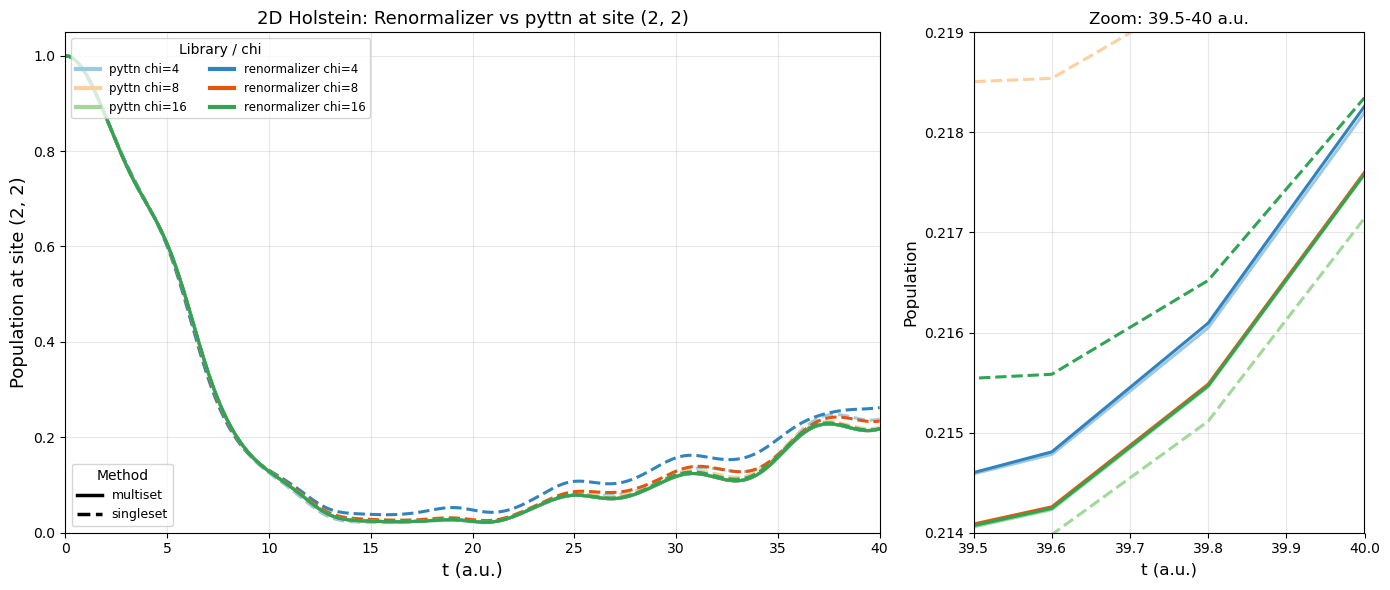

In [5]:
# =========================
# Compare all available Renormalizer / pyttn results in one figure
# =========================
from pathlib import Path
import re

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

target_coord = (2, 2)
target_index_renorm = target_coord[0] * 5 + target_coord[1]
dt_renorm = 0.2
zoom_window = (39.5, 40.0)

renorm_plot_dir = Path('.')
pyttn_root = Path('../../../../pyttn/test_multiset/test_2DHolstein25')

chi_colors = {
    4: {'pyttn': '#9ecae1', 'renormalizer': '#3182bd'},
    8: {'pyttn': '#fdd0a2', 'renormalizer': '#e6550d'},
    16: {'pyttn': '#a1d99b', 'renormalizer': '#31a354'},
    32: {'pyttn': '#fcbba1', 'renormalizer': '#de2d26'},
}
line_styles = {'singleset': '--', 'multiset': '-'}
library_order = {'pyttn': 0, 'renormalizer': 1}
ansatz_order = {'multiset': 0, 'singleset': 1}

def load_renorm_excel(path, site_index=target_index_renorm, dt=dt_renorm):
    df = pd.read_excel(path, header=None)
    if np.array_equal(df.iloc[0].to_numpy(), np.arange(df.shape[1])):
        df = df.iloc[1:].reset_index(drop=True)
    arr = df.to_numpy(dtype=float)
    time = np.arange(arr.shape[0], dtype=float) * dt
    return time, arr[:, site_index]

def load_pyttn_h5(path, target_coord=target_coord):
    with h5py.File(path, 'r') as handle:
        coords = handle['site_coordinates'][:]
        matches = [i for i, xy in enumerate(coords) if tuple(map(int, xy)) == target_coord]
        if len(matches) != 1:
            raise ValueError(f'Cannot find unique site {target_coord} in {path}')
        site_index = matches[0]
        time = handle['time'][:]
        occupation = handle['populations'][:, site_index]
        chi = int(handle.attrs.get('chi', 16))
    return time, occupation, chi

series = []

for path in sorted(renorm_plot_dir.glob('2DHolstein25_chi*_*.xlsx')):
    match = re.match(r'2DHolstein25_chi(\d+)_(singleset|multiset)\.xlsx$', path.name)
    if match is None:
        continue
    chi = int(match.group(1))
    ansatz = match.group(2)
    if chi == 32:
        continue
    time, occupation = load_renorm_excel(path)
    series.append({
        'library': 'renormalizer',
        'ansatz': ansatz,
        'chi': chi,
        'file': str(path),
        'time': time,
        'occupation': occupation,
    })

for ansatz in ['singleset', 'multiset']:
    for path in sorted((pyttn_root / ansatz).glob(f'holstein2d25_{ansatz}*.h5')):
        time, occupation, chi = load_pyttn_h5(path)
        series.append({
            'library': 'pyttn',
            'ansatz': ansatz,
            'chi': chi,
            'file': str(path),
            'time': time,
            'occupation': occupation,
        })

deduped = {}
for item in series:
    key = (item['library'], item['ansatz'], item['chi'])
    prev = deduped.get(key)
    prefer_current = prev is None or ('_chi' in Path(item['file']).stem and '_chi' not in Path(prev['file']).stem)
    if prefer_current:
        deduped[key] = item
series = sorted(
    deduped.values(),
    key=lambda x: (x['chi'], library_order[x['library']], ansatz_order[x['ansatz']]),
)

summary = pd.DataFrame([
    {
        'library': item['library'],
        'ansatz': item['ansatz'],
        'chi': item['chi'],
        'file': Path(item['file']).name,
        'n_points': len(item['time']),
    }
    for item in series
]).sort_values(['chi', 'library', 'ansatz']).reset_index(drop=True)
display(summary)

fig, (ax, ax_zoom) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2.5, 1.2]})

zoom_values = []
for item in series:
    color = chi_colors[item['chi']][item['library']]
    linestyle = line_styles[item['ansatz']]
    label = f"{item['library']} {item['ansatz']} chi={item['chi']}"
    ax.plot(item['time'], item['occupation'], linestyle=linestyle, color=color, linewidth=2.2, label=label)
    ax_zoom.plot(item['time'], item['occupation'], linestyle=linestyle, color=color, linewidth=2.2)
    mask = (item['time'] >= zoom_window[0]) & (item['time'] <= zoom_window[1])
    if np.any(mask):
        zoom_values.append(item['occupation'][mask])

ax.set_xlim(0, 40)
ax.set_ylim(bottom=0)
ax.set_xlabel('t (a.u.)', fontsize=13)
ax.set_ylabel('Population at site (2, 2)', fontsize=13)
ax.set_title('2D Holstein: Renormalizer vs pyttn at site (2, 2)', fontsize=13)
ax.grid(True, alpha=0.3)

ax_zoom.set_xlim(*zoom_window)

if zoom_values:
    zoom_concat = np.concatenate(zoom_values)
    y_min = float(zoom_concat.min())
    y_max = float(zoom_concat.max())
    pad = max(0.003, 0.08 * (y_max - y_min))
    ax_zoom.set_ylim(y_min - pad, y_max + pad)
ax_zoom.set_xlabel('t (a.u.)', fontsize=12)
ax_zoom.set_ylabel('Population', fontsize=12)
ax_zoom.set_ylim(0.214,0.219)
ax_zoom.set_title('Zoom: 39.5-40 a.u.', fontsize=12)
ax_zoom.grid(True, alpha=0.3)

color_handles = []
available_chis = sorted({item['chi'] for item in series})
for library in ['pyttn', 'renormalizer']:
    for chi in available_chis:
        if any(item['chi'] == chi and item['library'] == library for item in series):
            color_handles.append(Line2D([0], [0], color=chi_colors[chi][library], lw=3, label=f'{library} chi={chi}'))

style_handles = [
    Line2D([0], [0], color='black', lw=2.5, linestyle='-', label='multiset'),
    Line2D([0], [0], color='black', lw=2.5, linestyle='--', label='singleset'),
]

legend_colors = ax.legend(handles=color_handles, fontsize=8.5, ncol=2, loc='upper left', frameon=True, title='Library / chi')
ax.add_artist(legend_colors)
ax.legend(handles=style_handles, fontsize=9, loc='lower left', frameon=True, title='Method')

fig.tight_layout()
plt.show()

